# 03 · Exposure model

No public source counts how many seconds each car is on screen. So the model **allocates** car-focused coverage across the field, calibrated to published benchmarks, and carries every uncertain assumption through a Monte Carlo simulation.

**Coverage share for car *i* in a race**

$$s_i = (1-\varphi)\,\frac{e^{-\alpha(\bar p_i - 1)}}{\sum_j e^{-\alpha(\bar p_j - 1)}} \; + \; \varphi\,\frac{\text{laps led}_i}{\text{race laps}} \; + \; \kappa\,\mathbb{1}[\text{crashed}_i] \qquad \text{(renormalized to 1)}$$

- $\bar p_i$: average running position. Coverage decays exponentially from the front.
- $\varphi$: share of coverage that follows the leader.
- $\kappa$: extra coverage (replays) for a car that crashes out.
- $\alpha$ is **solved**, not assumed, so the top 10 cars take about half of coverage (Relo Metrics' benchmark for NASCAR broadcasts).

**Seconds and dollars**

$$\text{clear seconds}_i = s_i \times \text{coverage minutes} \times 60 \times (1-\text{ad load}) \times \text{car shots} \times \text{cars per shot} \times \text{logo clarity}$$
$$\text{value}_i = \frac{\text{clear seconds}_i}{30} \times \text{CPM} \times \text{audience (thousands)} \times \text{primary sponsor share}$$

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import duckdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from viz import use_style, money_axis, headline, source, SEQ, ordinal, FIELD, NY, THIRD, INK, INK_2, CONTEXT
import matplotlib
use_style()
pd.set_option("display.max_columns", 20, "display.width", 140)
ROOT = Path.cwd().parent
con = duckdb.connect(str(ROOT / "data" / "nascar_2025.duckdb"), read_only=True)
from model import PARAMS, load_starters, prepare, _shares, solve_alpha, p_qualify_daytona500, DAYTONA_500
df = pd.read_csv(ROOT / "data/processed/car_race_value.csv", dtype={"car_number": str})
V = np.load(ROOT / "data/processed/mc_values.npy")
draws = pd.read_csv(ROOT / "data/processed/mc_draws.csv")

## Assumptions

Each is drawn uniformly within its range in every simulation. Two are anchored to published data; the rest are stated assumptions whose influence is measured in the sensitivity analysis below.

In [2]:
pd.DataFrame([{"parameter": k, "low": lo, "high": hi, "basis": b} for k, (lo, hi, b) in PARAMS.items()]).style.hide(axis="index").format(precision=3)

parameter,low,high,basis
coverage_min,150.000,200.000,Assumption: green-to-checkered coverage minutes for a Cup race
ad_load,0.200,0.300,Assumption: share of race coverage in national commercial breaks
car_shot_share,0.550,0.800,"Assumption: share of race coverage showing cars (vs booth, pit, crowd, graphics)"
cars_per_shot,1.500,2.500,Assumption: average number of cars identifiable per shot
clear_share,0.250,0.500,Assumption: share of on-screen time a car's primary logos are clear and in focus; Relo Metrics reports ~20% of NASCAR frames are blurry
phi,0.100,0.250,Assumption: share of car coverage that follows the leader (Rotthoff et al. 2014: laps led drive exposure)
top10_target,0.450,0.550,Relo Metrics: cameras focus on the top 10 for about half of each race
crash_bonus,0.005,0.020,Assumption: extra share of coverage for each car that crashes out (replays)
cpm,25.000,55.000,Assumption: CPM for a regular Cup race; below the Daytona 500 anchor
cpm_daytona500,59.000,74.000,"SBJ via Awful Announcing: 2025 Daytona 500 spots mostly $400-450K, some $500K+, 6.761M viewers"


## 1 · How coverage is allocated

The decay rate α controls how steeply camera time falls off from the front. Using the Nashville field as an example:

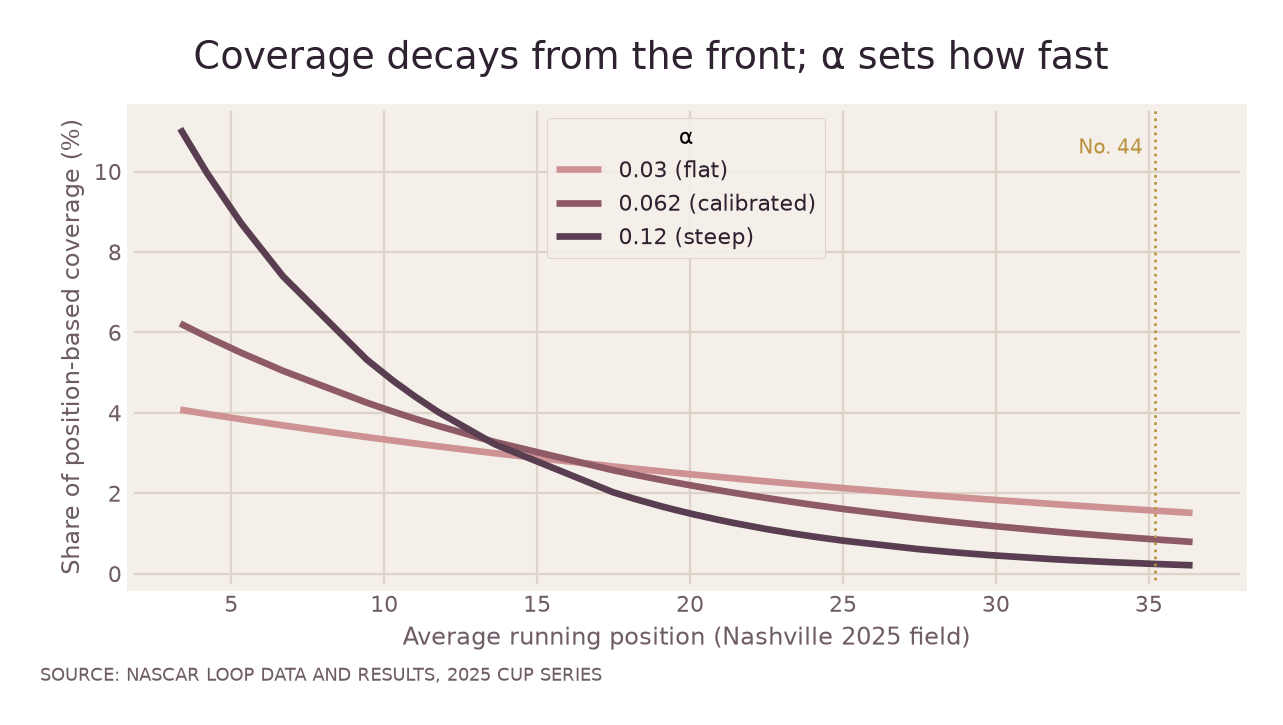

In [3]:
nash = df[df.race_id == 5568].sort_values("avg_ps")
p = nash.avg_ps.values
fig, ax = plt.subplots(figsize=(8, 3.8))
for a, c, lab in zip([0.03, np.median(draws.alpha), 0.12], ordinal(3), ["0.03 (flat)", f"{np.median(draws.alpha):.3f} (calibrated)", "0.12 (steep)"]):
    w = np.exp(-a * (p - 1)); ax.plot(p, w / w.sum() * 100, color=c, label=lab)
y44 = nash.loc[nash.is_ny_racing, "avg_ps"].iloc[0]
ax.axvline(y44, color=NY, lw=1.2, ls=":"); ax.text(y44 - 0.4, ax.get_ylim()[1] * 0.9, "No. 44", color=NY, ha="right", fontsize=9)
ax.set_xlabel("Average running position (Nashville 2025 field)"); ax.set_ylabel("Share of position-based coverage (%)")
headline(fig, "Coverage decays from the front; α sets how fast"); ax.legend(title="α")
source(fig); plt.show()

## 2 · Calibration

For each simulation, α is solved by bisection so the mean top-10 share across all 36 races equals that draw's target (45–55%). The curve below shows why a unique solution exists: top-10 share rises monotonically with α.

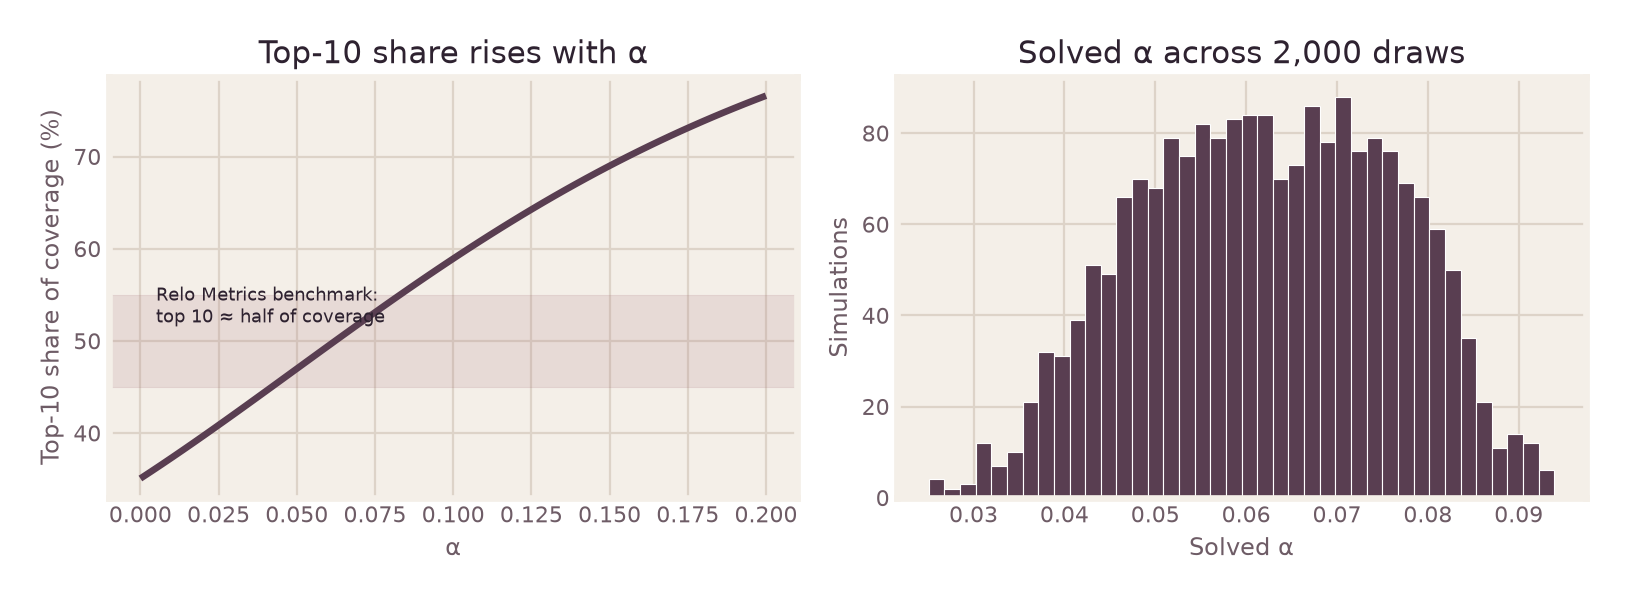

mean    0.0622
std     0.0138
min     0.0251
max     0.0939
Name: alpha, dtype: float64

In [4]:
d, race_idx, n_races, top10 = prepare(load_starters())
alphas = np.linspace(0, 0.2, 60)
t10 = [np.bincount(race_idx, _shares(d.avg_ps.values, d.lead_frac.values, d.crashed.values, race_idx, n_races, a, 0.175, 0.0125) * top10, minlength=n_races).mean() for a in alphas]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))
ax1.plot(alphas, np.array(t10) * 100, color=FIELD)
ax1.axhspan(45, 55, color=THIRD, alpha=0.15); ax1.text(0.005, 52, "Relo Metrics benchmark:\ntop 10 ≈ half of coverage", fontsize=8, color=INK)
ax1.set_xlabel("α"); ax1.set_ylabel("Top-10 share of coverage (%)"); ax1.set_title("Top-10 share rises with α")
ax2.hist(draws.alpha, bins=40, color=FIELD, edgecolor="white", linewidth=0.5)
ax2.set_xlabel("Solved α"); ax2.set_ylabel("Simulations"); ax2.set_title(f"Solved α across {len(draws):,} draws")
fig.tight_layout(); plt.show()
draws.alpha.describe()[["mean", "std", "min", "max"]].round(4)

## 3 · The simulated assumptions

Small multiples of what each draw used. Uniform by design: the model does not claim to know more than the ranges.

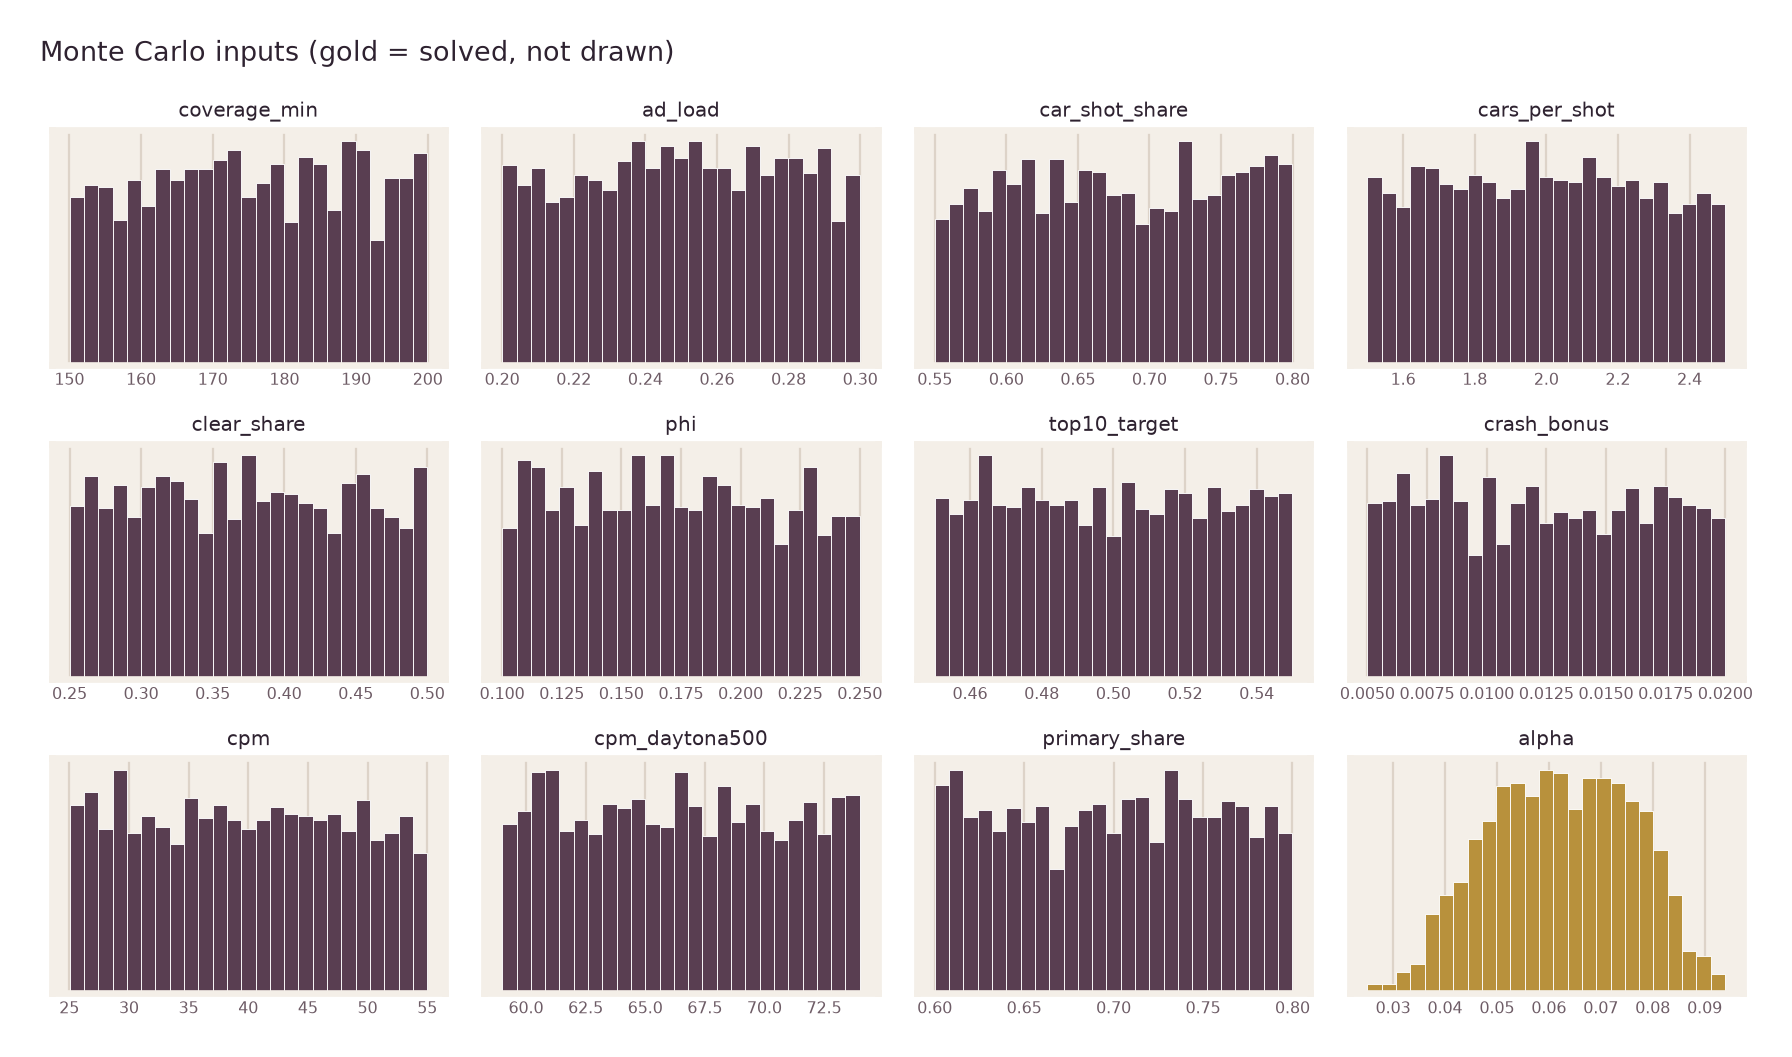

In [5]:
cols = [c for c in PARAMS]
fig, axes = plt.subplots(3, 4, figsize=(11, 6.4))
for ax, c in zip(axes.flat, cols + ["alpha"]):
    ax.hist(draws[c], bins=25, color=FIELD if c != "alpha" else NY, edgecolor="white", linewidth=0.4)
    ax.set_title(c, fontsize=9); ax.tick_params(labelsize=7); ax.set_yticks([])
fig.suptitle("Monte Carlo inputs (gold = solved, not drawn)", x=0.01, ha="left", fontsize=12, color=INK)
fig.tight_layout(); plt.show()

## 4 · Convergence

Is 2,000 draws enough? The running median of the No. 44's season value flattens well before the end.

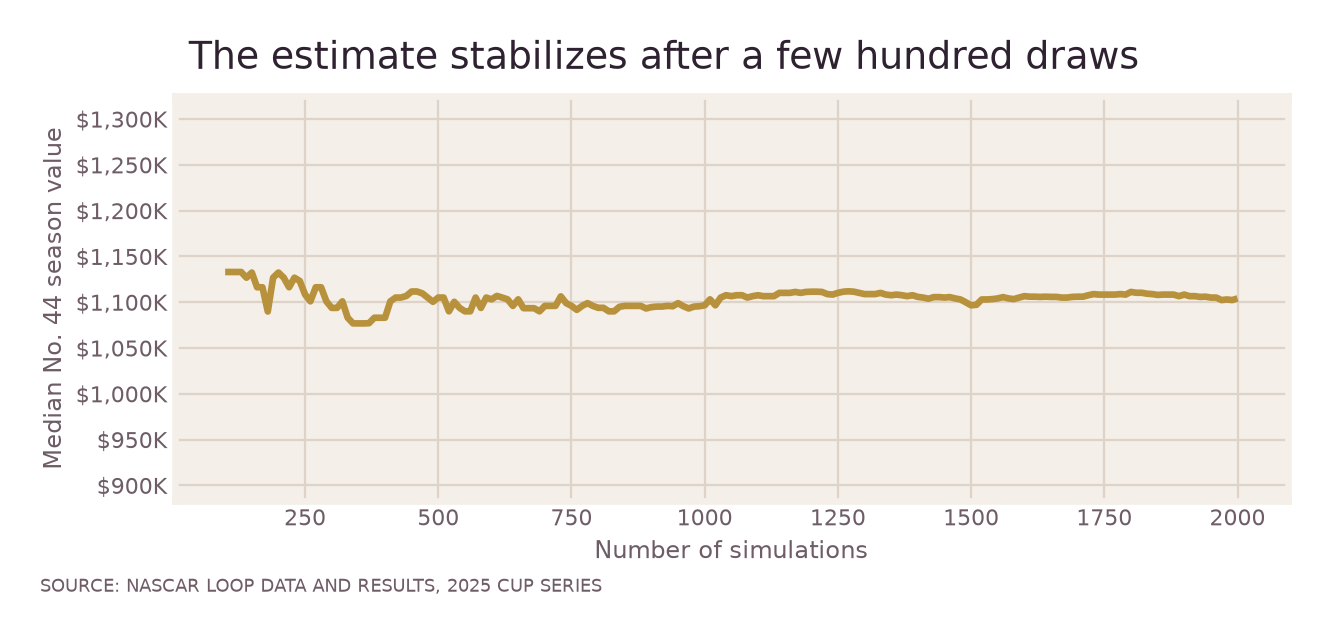

change over the last 1,000 draws: 0.1%


In [6]:
ny_mask = df.is_ny_racing.values
ny_season = V[:, ny_mask].sum(1)
running = [np.median(ny_season[:k]) for k in range(100, len(ny_season) + 1, 10)]
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(range(100, len(ny_season) + 1, 10), running, color=NY)
money_axis(ax, "y", "K"); ax.set_ylim(running[-1] * 0.8, running[-1] * 1.2); ax.set_xlabel("Number of simulations"); ax.set_ylabel("Median No. 44 season value")
headline(fig, "The estimate stabilizes after a few hundred draws")
source(fig); plt.show()
print(f"change over the last 1,000 draws: {abs(running[-1] - running[-100]) / running[-1]:.1%}")

## 5 · Result distribution: the No. 44's 2025 season

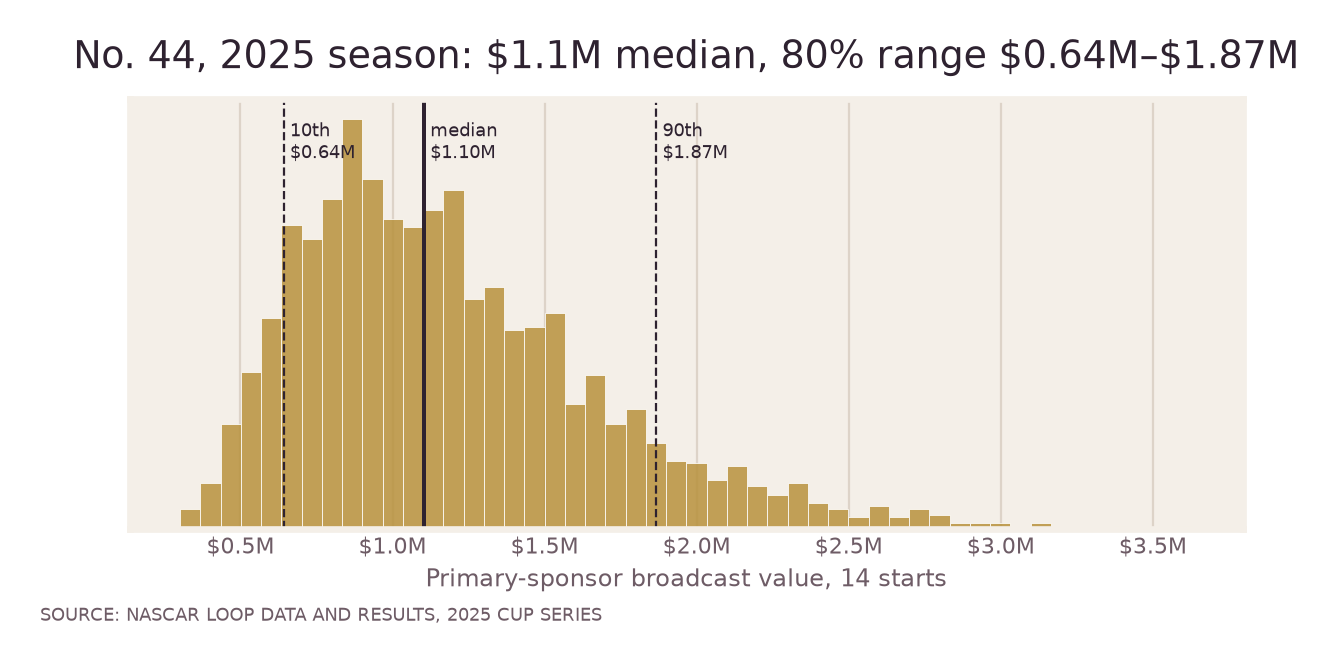

In [7]:
q10, q50, q90 = np.quantile(ny_season, [0.1, 0.5, 0.9])
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.hist(ny_season, bins=50, color=NY, alpha=0.85, edgecolor="white", linewidth=0.4)
for v, lab in [(q10, "10th"), (q50, "median"), (q90, "90th")]:
    ax.axvline(v, color=INK, lw=1 if lab != "median" else 1.8, ls="--" if lab != "median" else "-")
    ax.text(v, ax.get_ylim()[1] * 0.95, f" {lab}\n ${v/1e6:.2f}M", fontsize=8, color=INK, va="top")
money_axis(ax, "x", "M"); ax.set_yticks([]); ax.set_xlabel("Primary-sponsor broadcast value, 14 starts")
headline(fig, "No. 44, 2025 season: $1.1M median, 80% range $0.64M–$1.87M")
source(fig); plt.show()

## 6 · Qualification model

At the 2025 Daytona 500, 8 open cars competed for 4 spots (a fifth open car entered on a provisional). With a uniform prior, the chance an open car makes it is Beta(5, 5).

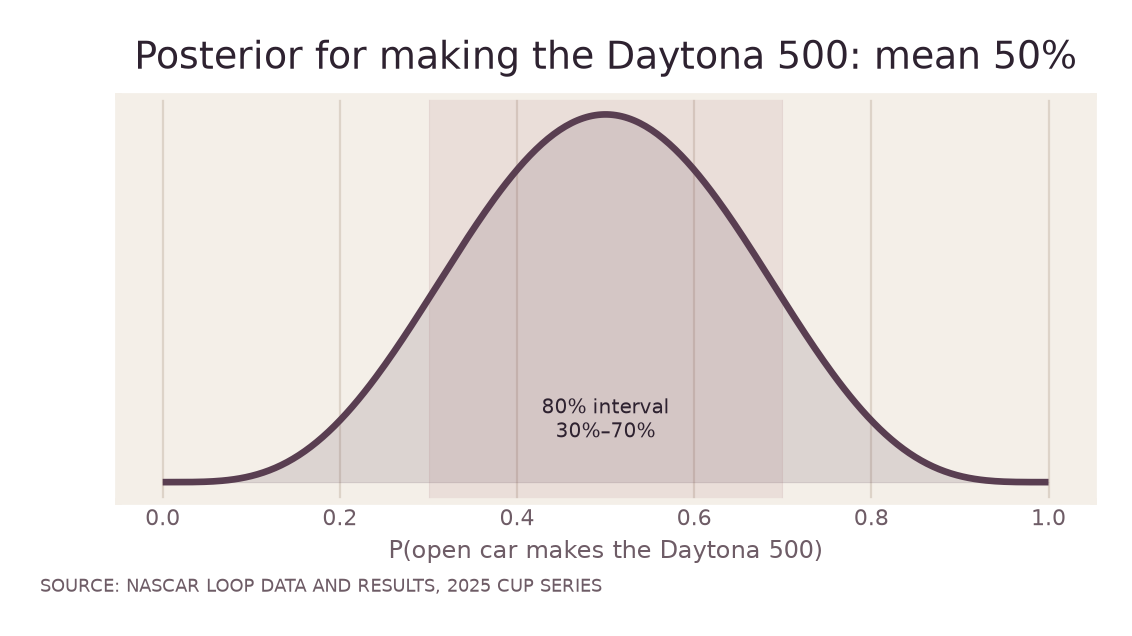

In [8]:
from scipy.stats import beta
xs = np.linspace(0, 1, 300)
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(xs, beta.pdf(xs, 5, 5), color=FIELD); ax.fill_between(xs, beta.pdf(xs, 5, 5), color=FIELD, alpha=0.15)
lo, hi = beta.ppf([0.1, 0.9], 5, 5)
ax.axvspan(lo, hi, color=THIRD, alpha=0.12); ax.text(0.5, 0.3, f"80% interval\n{lo:.0%}–{hi:.0%}", ha="center", fontsize=9, color=INK)
ax.set_xlabel("P(open car makes the Daytona 500)"); ax.set_yticks([])
headline(fig, "Posterior for making the Daytona 500: mean 50%")
source(fig); plt.show()

## 7 · Sensitivity

One assumption at a time moved to the low and high end of its range, the rest held at midpoints. CPM and logo clarity matter most; the crash-coverage assumption barely moves the season total, because it shifts value between races (Atlanta up, the rest down) rather than adding it.

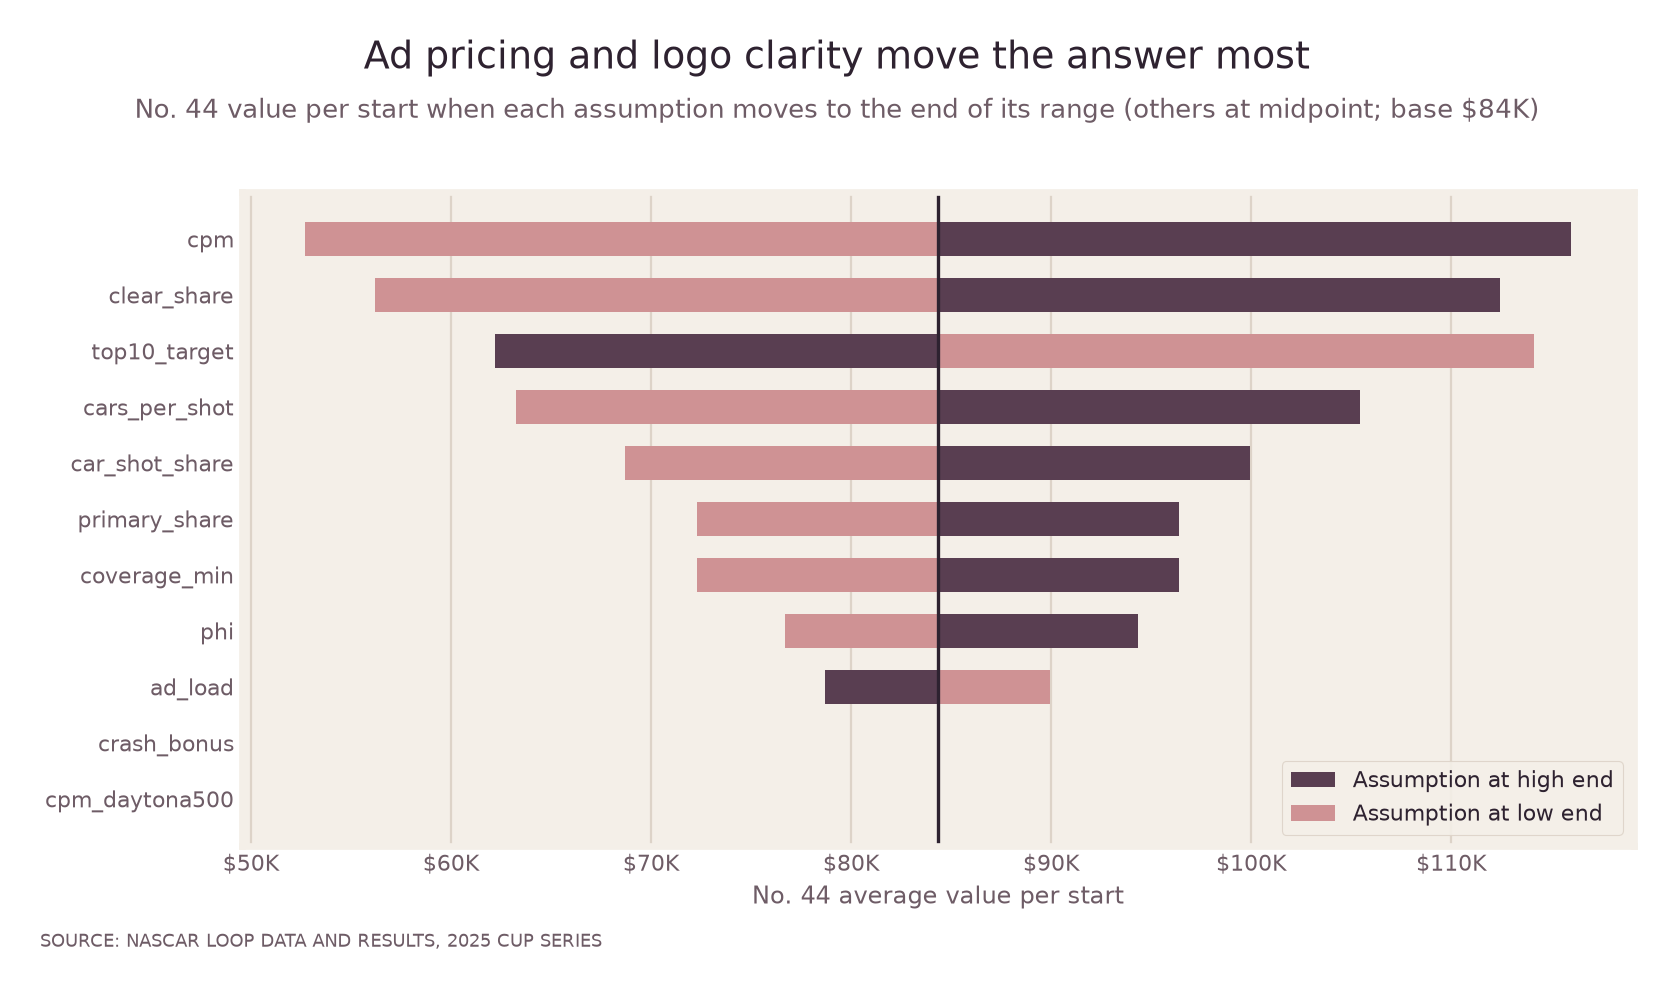

,param,value_at_low,value_at_high,swing
0,cpm,52712.0,115966.0,63254.0
1,clear_share,56226.0,112452.0,56226.0
2,top10_target,114148.0,62214.0,51934.0
3,cars_per_shot,63254.0,105424.0,42170.0
4,car_shot_share,68721.0,99957.0,31237.0
5,primary_share,72291.0,96388.0,24097.0
6,coverage_min,72291.0,96388.0,24097.0
7,phi,76692.0,94339.0,17647.0
8,ad_load,89962.0,78717.0,11245.0
9,crash_bonus,84383.0,84402.0,19.0


In [9]:
from IPython.display import Image
display(Image(str(ROOT / "images/sensitivity.png"), width=520))
pd.read_csv(ROOT / "data/processed/sensitivity.csv")[["param", "value_at_low", "value_at_high", "swing"]].sort_values("swing", ascending=False).round(0).reset_index(drop=True)

### Value surface for the two biggest assumptions

The sensitivity chart moves one assumption at a time. This grid moves the two biggest together. Value scales linearly in both, so every cell is exact given the other assumptions at their midpoints. The dashed line marks where broadcast value alone reaches a $75K per-race price.

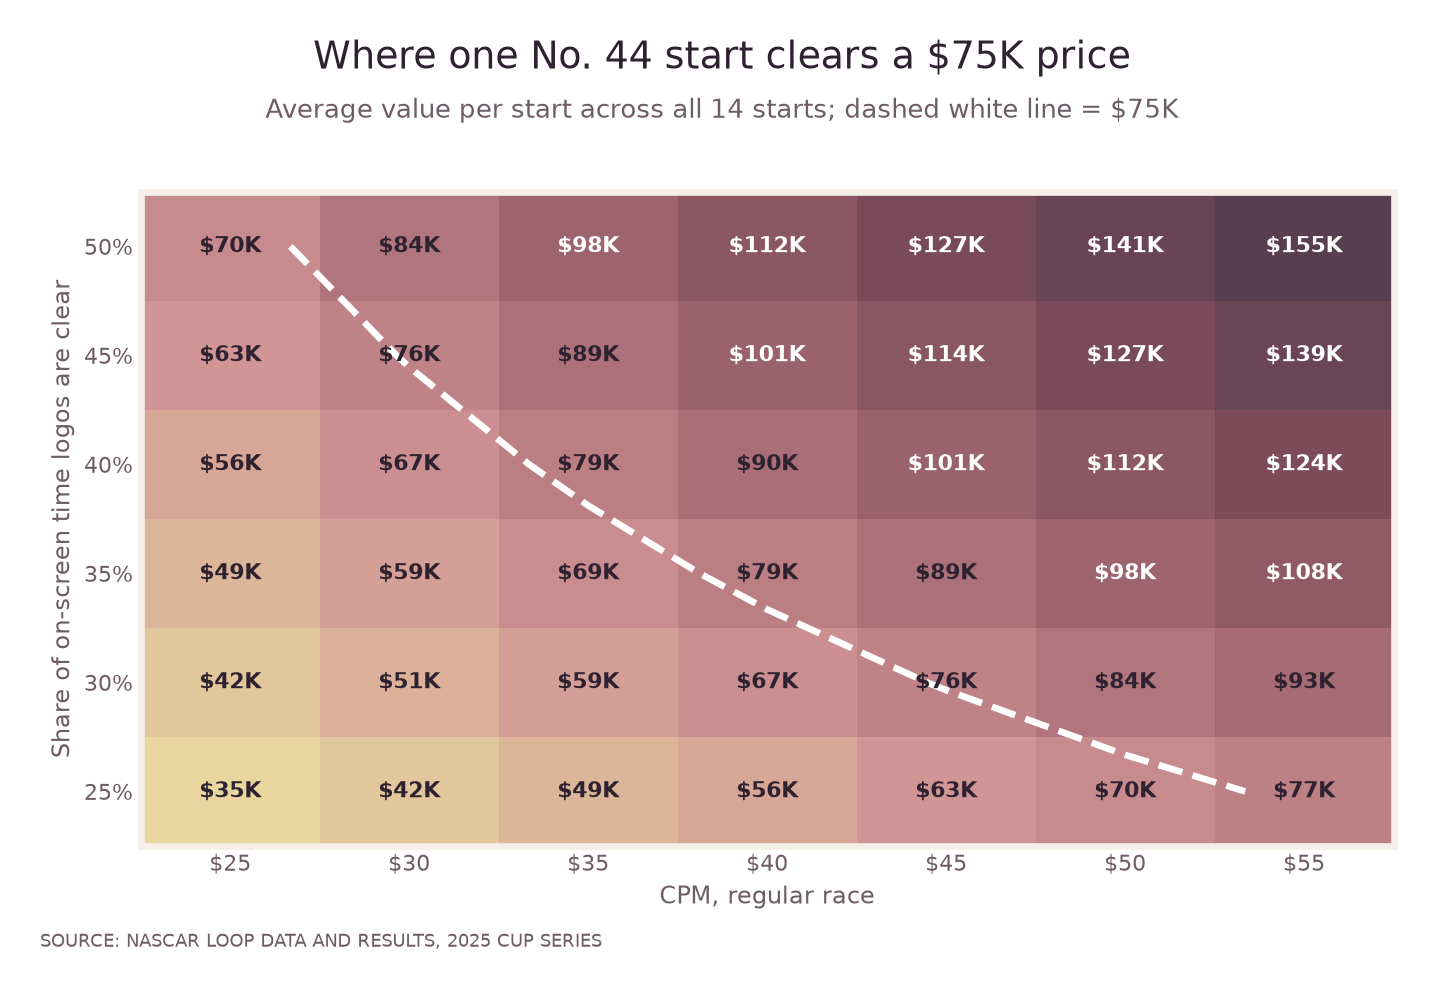

In [10]:
sens = pd.read_csv(ROOT / "data/processed/sensitivity.csv")
base = sens.loc[sens.param == "cpm", ["value_at_low", "value_at_high"]].values.mean()
cpms = np.arange(25, 56, 5); clears = np.round(np.arange(0.25, 0.51, 0.05), 2)
grid = np.array([[base * (c / 40) * (k / 0.375) for c in cpms] for k in clears])
fig, ax = plt.subplots(figsize=(9, 5.6))
ax.imshow(grid / 1e3, cmap=SEQ, aspect="auto", origin="lower")
for i in range(len(clears)):
    for j in range(len(cpms)):
        v = grid[i, j] / 1e3; ax.text(j, i, f"${v:,.0f}K", ha="center", va="center", fontsize=10, fontweight="bold", color="white" if v > grid.max() / 1e3 * 0.6 else INK)
ax.contour(grid, levels=[75_000], colors=["white"], linewidths=3, linestyles="--")
ax.set_xticks(range(len(cpms)), [f"${c}" for c in cpms]); ax.set_yticks(range(len(clears)), [f"{k:.0%}" for k in clears]); ax.grid(False)
ax.set_xlabel("CPM, regular race"); ax.set_ylabel("Share of on-screen time logos are clear")
headline(fig, "Where one No. 44 start clears a $75K price", "Average value per start across all 14 starts; dashed white line = $75K")
source(fig); plt.show()

### Robustness: does the pricing finding depend on the guesses?

The two coverage assumptions change the *shape* of camera time, not just its scale, so they are the ones that could overturn a finding. Each row fixes one of them at four levels and redraws every other assumption 100 times. The left column shows the value curve, the middle shows the No. 44's value per start, and the right asks the question the pricing rests on: does a backmarker start on FOX still beat one on USA?

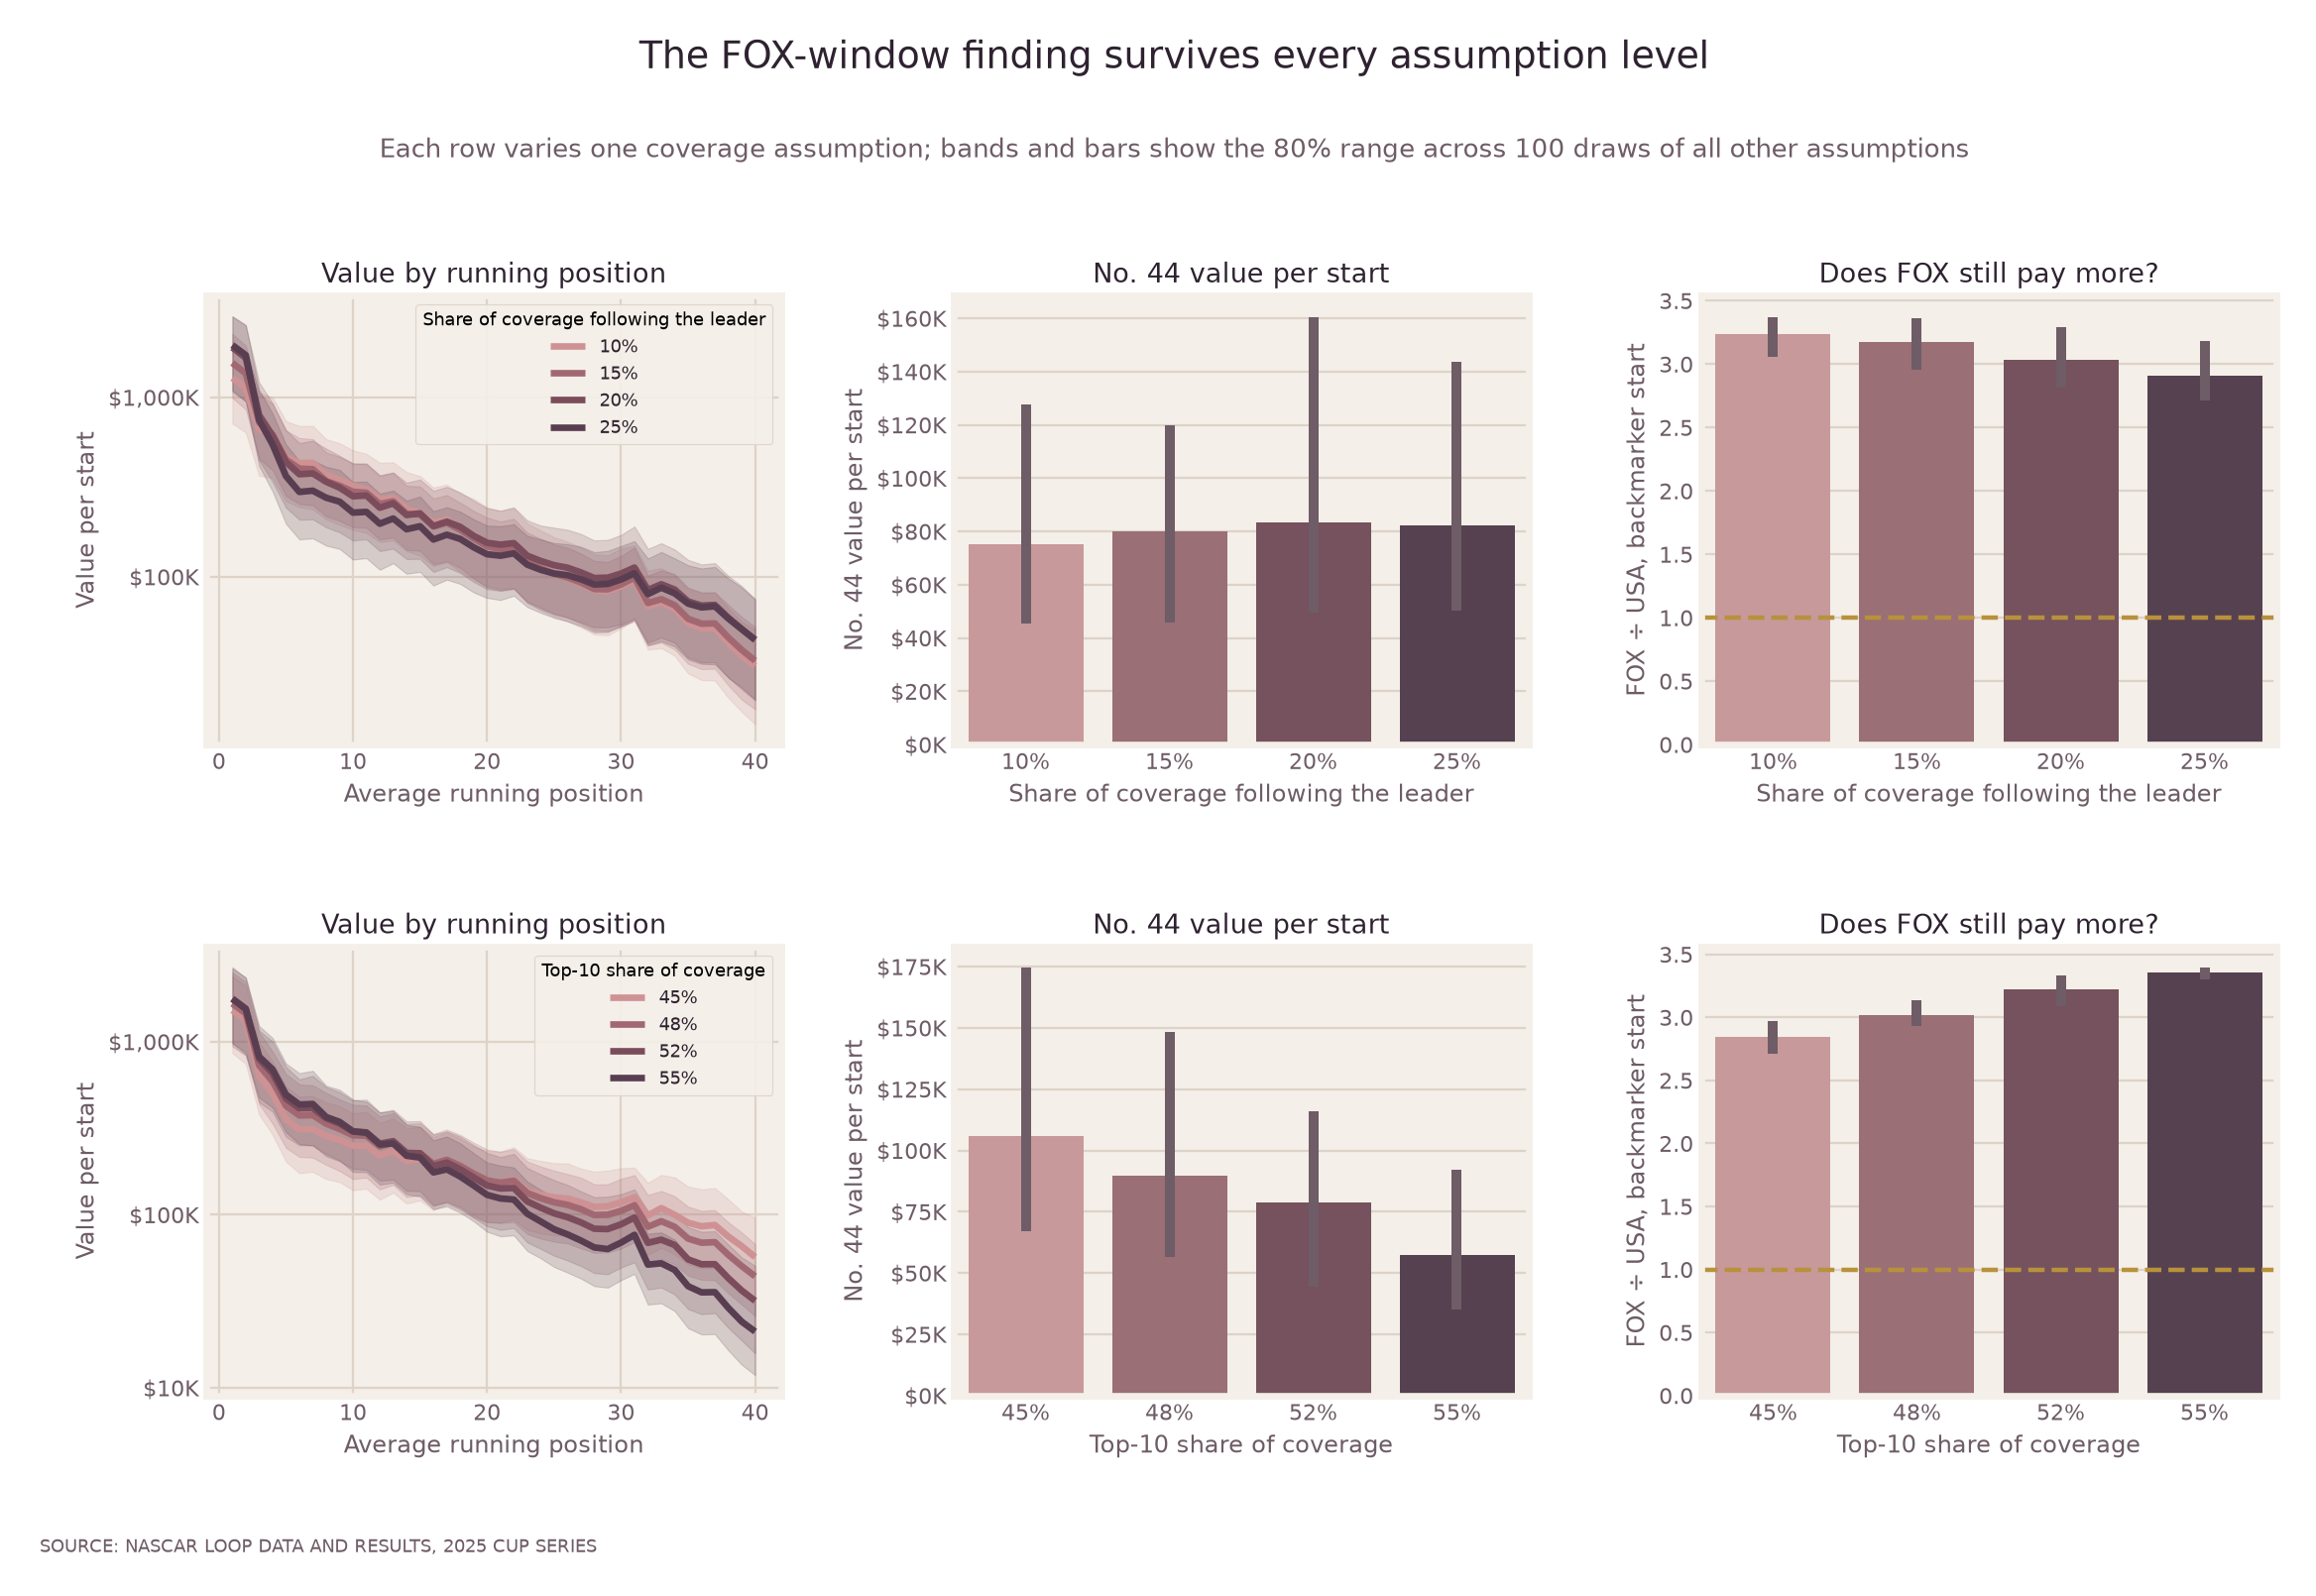

ny_per_start  fox_vs_usa
param        level                          
phi          10%        75123.71        3.23
             15%        80136.67        3.18
             20%        83551.02        3.04
             25%        82436.45        2.91
top10_target 45%       106044.48        2.84
             48%        89535.65        3.02
             52%        78752.01        3.23
             55%        57297.56        3.36

In [11]:
import seaborn as sns

d, race_idx, n_races, top10 = prepare(load_starters())
rank_pct = d.groupby("race_id").avg_ps.rank(pct=True).values
backmarker = (rank_pct >= 0.75) & (d.lead_laps.values == 0) & (d.crashed.values == 0)
fox_b, usa_b = backmarker & (d.broadcaster.values == "FOX"), backmarker & (d.broadcaster.values == "USA")
ny = d.is_ny_racing.values
pos_bin = np.clip(np.round(d.avg_ps.values), 1, 40)
rng = np.random.default_rng(7)

def run(param, level):
    p = {k: rng.uniform(lo, hi) for k, (lo, hi, _) in PARAMS.items()}
    p[param] = level
    a = solve_alpha(d, race_idx, n_races, top10, p["phi"], p["crash_bonus"], p["top10_target"])
    s = _shares(d.avg_ps.values, d.lead_frac.values, d.crashed.values, race_idx, n_races, a, p["phi"], p["crash_bonus"])
    pool = p["coverage_min"] * 60 * (1 - p["ad_load"]) * p["car_shot_share"] * p["cars_per_shot"] * p["clear_share"]
    cpm = np.where(d.race_id.values == DAYTONA_500, p["cpm_daytona500"], p["cpm"])
    return s * pool / 30 * cpm * d.viewers_m.values * 1000 * p["primary_share"]

TESTS = {"phi": "Share of coverage following the leader", "top10_target": "Top-10 share of coverage"}
curves, outcomes = [], []
for param in TESTS:
    lo, hi, _ = PARAMS[param]
    for level in np.linspace(lo, hi, 4):
        lab = f"{level:.0%}"
        for draw in range(100):
            v = run(param, level)
            c = pd.DataFrame({"pos": pos_bin, "value": v}).groupby("pos").value.median()
            curves.append(pd.DataFrame({"param": param, "level": lab, "pos": c.index, "value": c.values}))
            outcomes.append({"param": param, "level": lab, "ny_per_start": v[ny].mean(),
                             "fox_vs_usa": np.median(v[fox_b]) / np.median(v[usa_b])})
curves, outcomes = pd.concat(curves), pd.DataFrame(outcomes)

pal = ordinal(4)  # assumption level, low -> high: pale rose -> plum
fig, axes = plt.subplots(2, 3, figsize=(15, 9.5))
fig.subplots_adjust(hspace=0.45, wspace=0.3)
for row, (param, name) in enumerate(TESTS.items()):
    sns.lineplot(data=curves[curves.param == param], x="pos", y="value", hue="level", palette=pal,
                 errorbar=("pi", 80), ax=axes[row, 0])
    axes[row, 0].set_yscale("log"); axes[row, 0].set_xlabel("Average running position")
    axes[row, 0].set_ylabel("Value per start"); axes[row, 0].legend(title=name, fontsize=8, title_fontsize=8)
    axes[row, 0].yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f"${x/1e3:,.0f}K"))
    axes[row, 0].set_title("Value by running position", fontsize=12)
    o = outcomes[outcomes.param == param]
    sns.barplot(data=o, x="level", y="ny_per_start", hue="level", palette=pal, estimator="median", errorbar=("pi", 80),
                err_kws={"color": INK_2}, legend=False, ax=axes[row, 1])
    money_axis(axes[row, 1], "y", "K"); axes[row, 1].set_xlabel(name); axes[row, 1].set_ylabel("No. 44 value per start")
    axes[row, 1].set_title("No. 44 value per start", fontsize=12)
    sns.barplot(data=o, x="level", y="fox_vs_usa", hue="level", palette=pal, estimator="median", errorbar=("pi", 80),
                err_kws={"color": INK_2}, legend=False, ax=axes[row, 2])
    axes[row, 2].axhline(1, color=NY, lw=2, ls="--")
    axes[row, 2].set_xlabel(name); axes[row, 2].set_ylabel("FOX ÷ USA, backmarker start")
    axes[row, 2].set_title("Does FOX still pay more?", fontsize=12)
    for ax in axes[row, 1:]: ax.grid(axis="x", visible=False)
headline(fig, "The FOX-window finding survives every assumption level",
         "Each row varies one coverage assumption; bands and bars show the 80% range across 100 draws of all other assumptions")
source(fig); plt.show()
outcomes.groupby(["param", "level"]).agg(ny_per_start=("ny_per_start", "median"), fox_vs_usa=("fox_vs_usa", "median")).round(2)

**Result.** A backmarker start on FOX is worth 2.8–3.4× one on USA at every level of both assumptions, never close to 1, so the network recommendation does not depend on either guess. The price level does: the No. 44's value per start ranges from about $106K to $57K across the top-10 assumption. That is why the value sheet quotes ranges, and why the hand-coded replay sample, which measures the top-10 share directly, is the most useful next step.

## 8 · Checks against the outside world

**Benchmark.** Rotthoff et al. report mean exposure value of $38.6M per driver-season for 2001–2007 (Joyce Julius data: every logo plus verbal mentions, audiences roughly three times today's). Scaling that to 2025 audiences and to clear primary-sponsor logo time only should land near this model's average.

In [12]:
per_car = V.sum(1).mean() / df.car_number.nunique()
full_time = V[:, df.groupby("car_number").race_id.transform("count").values == 36].sum(1).mean() / 36
aud_ratio = 7.0 / df.groupby("race_id").viewers_m.first().mean()
print(f"Model: mean value per full-time car-season   ${full_time/1e6:.1f}M")
print(f"Rotthoff et al. (2001-07) scaled by audience  ${38.6/aud_ratio:.1f}M  (before removing verbal mentions and non-primary logos)")

Model: mean value per full-time car-season   $9.2M
Rotthoff et al. (2001-07) scaled by audience  $13.5M  (before removing verbal mentions and non-primary logos)


**Calculator consistency.** The browser calculator recomputes value from 400 thinned draws and a reference field. It should agree with the full model for the same inputs.

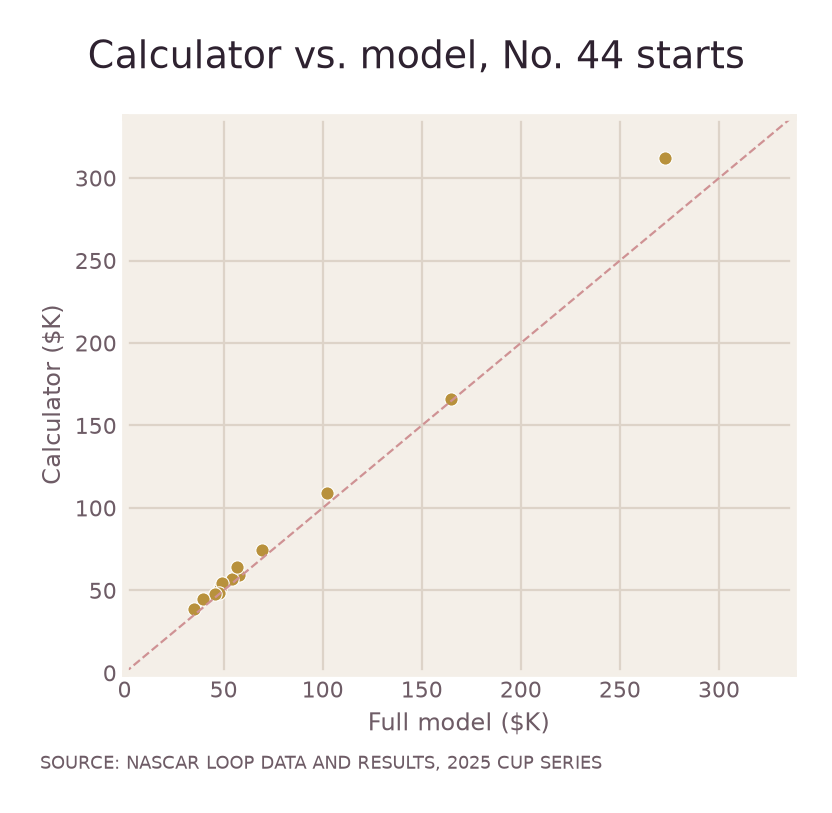

median absolute difference: 7.0%, worst: 14.6%


In [13]:
d500 = pd.read_csv(ROOT / "data/processed/backmarker_run_by_race.csv")
data = json.loads((ROOT / "app/model_data.json").read_text()); D = data["draws"]
def calc(race_id, pos, lead=0.0, crashed=False):
    field = np.array(data["reference_field"]); field[np.abs(field - pos).argmin()] = pos
    vw = next(r["viewers_m"] for r in data["races"] if r["race_id"] == race_id); out = []
    for i in range(len(D["alpha"])):
        w = np.exp(-D["alpha"][i] * (field - 1)); base = np.exp(-D["alpha"][i] * (pos - 1)) / w.sum()
        c = D["crash_bonus"][i] if crashed else 0; s_ = ((1 - D["phi"][i]) * base + D["phi"][i] * lead + c) / (1 + c)
        pool = D["coverage_min"][i] * 60 * (1 - D["ad_load"][i]) * D["car_shot_share"][i] * D["cars_per_shot"][i] * D["clear_share"][i]
        cpm = D["cpm_daytona500"][i] if race_id == DAYTONA_500 else D["cpm"][i]
        out.append(s_ * pool / 30 * cpm * vw * 1000 * D["primary_share"][i])
    return np.median(out)
rows = []
for _, r in df[df.is_ny_racing].iterrows():
    rows.append({"race": r.track_name, "model": r.value_p50, "calculator": calc(r.race_id, r.avg_ps, r.lead_frac if "lead_frac" in r else r.lead_laps / r.total_laps, "Accident" in str(r.status))})
cmp = pd.DataFrame(rows); cmp["diff"] = cmp.calculator / cmp.model - 1
fig, ax = plt.subplots(figsize=(4.8, 4.4))
ax.scatter(cmp.model / 1e3, cmp.calculator / 1e3, color=NY, s=36, edgecolor="white")
m = max(cmp.model.max(), cmp.calculator.max()) / 1e3 * 1.08
ax.plot([0, m], [0, m], color=CONTEXT, ls="--", lw=1); ax.set_xlim(0, m); ax.set_ylim(0, m)
ax.set_xlabel("Full model ($K)"); ax.set_ylabel("Calculator ($K)"); headline(fig, "Calculator vs. model, No. 44 starts")
source(fig); plt.show()
print(f"median absolute difference: {cmp['diff'].abs().median():.1%}, worst: {cmp['diff'].abs().max():.1%}")

## What this model does not do

- It is **calibrated, not measured**: camera time per car comes from an allocation rule, not frame counts. `docs/validation_protocol.md` is the plan to measure it.
- Networks differ only through **audience and price**. Whether one network spreads coverage further down the field is untested.
- It values **broadcast exposure only**: no social, earned media, hospitality or sales effects.

**Next:** [04 · Findings and pricing](04_findings_and_pricing.ipynb)